# Notebook Overview
# Character play Generator

This notebook demonstrates how to generate text using a character-based RNN. It works with a dataset of Shakespeare's writing from ```Andrej Karpathy's``` to demonstrate the effectiveness of Recurrent Neural Networks. The model seeks to answer that given a character, or a sequence of characters, what is the most probable next character? eg a sequence of characters from this data ("Shakespear"), train a model to predict the next character in the sequence ("e"). Longer sequences of text can be generated by calling the model repeatedly.

In [ ]:
#importing main utility
import tensorflow as tf

# Downloading dataset

In [ ]:
path = tf.keras.utils.get_file('shakespeare.txt', 'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt')

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
'''
opening the file in binary mode
reading it in binary mode
then decoding/ transferring to human readable text
using the utf-8 encoding
UTF-8 stands for Unicode Transformation Format - 8-bit
'''
with open(path,'rb') as f:
  text = f.read().decode(encoding = 'utf-8')
#length of all characters
print(len(text))

1115394


In [ ]:
# Visual of play
print(text[1000:4000])

Second Citizen:
Would you proceed especially against Caius Marcius?

All:
Against him first: he's a very dog to the commonalty.

Second Citizen:
Consider you what services he has done for his country?

First Citizen:
Very well; and could be content to give him good
report fort, but that he pays himself with being proud.

Second Citizen:
Nay, but speak not maliciously.

First Citizen:
I say unto you, what he hath done famously, he did
it to that end: though soft-conscienced men can be
content to say it was for his country he did it to
please his mother and to be partly proud; which he
is, even till the altitude of his virtue.

Second Citizen:
What he cannot help in his nature, you account a
vice in him. You must in no way say he is covetous.

First Citizen:
If I must not, I need not be barren of accusations;
he hath faults, with surplus, to tire in repetition.
What shouts are these? The other side o' the city
is risen: why stay we prating here? to the Capitol!

All:
Come, come.

First C

In [ ]:
#getting unique characters

vocab = sorted(set(text))
print(vocab)

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [ ]:
# mapping character to integers
import numpy as np
char2int = {char:index for index,char in enumerate(vocab)}

#print(char2int)
int2char = np.array(vocab) #vocab position in array corresponds directly to its index in the int2char dictionary
print(int2char)

['\n' ' ' '!' '$' '&' "'" ',' '-' '.' '3' ':' ';' '?' 'A' 'B' 'C' 'D' 'E'
 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R' 'S' 'T' 'U' 'V' 'W'
 'X' 'Y' 'Z' 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'j' 'k' 'l' 'm' 'n' 'o'
 'p' 'q' 'r' 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']


In [ ]:
def text2int(text):
  return np.array(list(char2int[char] for char in text)) #converts text to corresponding integers



In [ ]:
print("Text:", text[:13])
print("Encoded:", text2int(text[:13]))

def int2text(integer):

  try:
      integer = integer.numpy()
  except:
    pass

  return ''.join(int2char[integer])


print(int2text(text2int(text[:13])))


Text: First Citizen
Encoded: [18 47 56 57 58  1 15 47 58 47 64 43 52]
First Citizen


# Creating training examples

For each input sequence, the corresponding targets contain the same length of text, except shifted one character to the right.

For example, say seq_length is 4 and our text is "Hello". The input sequence would be "Hell", and the target sequence "ello".

To do this first use the tf.data.Dataset.from_tensor_slices function to convert the text vector into a stream of character indices.

In [ ]:
seq_length = 100  # length of sequence for a training example
examples_per_epoch = len(text)//(seq_length+1) #Takes a sequence of 100 characters and returns the next letter, for this 101 characters are needed
text_as_int  = text2int(text) #convert training data to integers


# Creating a stream of characters

```tf.data.Dataset.from_tensor_slices``` - slices along the first dimension(column wise)

Example

Original tensor: [72, 69, 76, 76, 79, 32, 87, 79, 82, 76, 68]
                  │
from_tensor_slices ────►  Dataset with 11 elements:
                  
                  Element 0: 72
                  Element 1: 69
                  Element 2: 76
                  Element 3: 76
                  Element 4: 79
                  Element 5: 32
                  Element 6: 87
                  Element 7: 79
                  Element 8: 82
                  Element 9: 76
                  Element 10: 68

  # Benefits

- Lazy loading-Data is loaded on-demand, not all at once
Prefetching	Prepares next batch while current batch trains
- Shuffling-Randomizes order to prevent overfitting
Caching	Can cache preprocessed data in RAM after first epoch
- Parallel mapping- map can run on multiple CPU cores
- Batch streaming	Never stores all batches in memory at once
Memory Comparison




In [ ]:
char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)
#batching sequences
#drop_remainder drops/discards caharcters that weren't able to fit into batches
sequences = char_dataset.batch(seq_length +1,drop_remainder= True) #batching allows creating of input to target stream

# Splitting inputs and targets from the sequence

In [ ]:
def split_input_target(sequence): #loops through all batches
  input = sequence[:-1]#everything except the last word
  target = sequence[1:]#apply a shift of one, effectively maps consecutive characters

  return input,target


# Mapping to each sequence

In [ ]:
input_target = sequences.map(split_input_target)



In [ ]:
# Visualizing

for x, y in input_target.take(2):
  print("\n\nEXAMPLE\n")
  print("INPUT")
  print(int2text(x))
  print("\nOUTPUT")
  print(int2text(y))




EXAMPLE

INPUT
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You

OUTPUT
irst Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You 


EXAMPLE

INPUT
are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you 

OUTPUT
re all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you k


In [ ]:
len(input_target)

11043

In [ ]:

# Batching and shuffling

batch_size = 64 # A single shuffle should have 64 sequences with a stream of 100 characters
buffer_size = 10000 #should be almost the same size as dataset
data = input_target.shuffle(buffer_size).batch(batch_size,drop_remainder=True)


# Building the model

In [ ]:
VOCAB_SIZE = len(vocab)  # vocab is number of unique characters
EMBEDDING_DIM = 256 #size of character embeddings
RNN_UNITS = 1024


In [ ]:
'''
creating model inside a function to allow for multiple calls
this is so as to allow text generation
stateful = True, allows model to retain its hidden state per batch
recurrent_initializer = 'glorot_uniform' sets the weights for training
batch size is important as it works hand in hand with stateful
setting the column parameter to None allows for flexibility when seq length changes
return sequence set to true as at each character we intend to get the next letter that follows it as target
'''
from tensorflow.keras.layers import Embedding,Dense,LSTM
from tensorflow.keras import Sequential
def build_model(vocab_size,embedding_dim,rnn_units,batch_size):
  model = Sequential([
      Embedding(vocab_size,embedding_dim), # Removed batch_input_shape from Embedding layer
      LSTM(rnn_units,
           return_sequences = True,
           stateful = True,
           recurrent_initializer = 'glorot_uniform'),
      Dense(vocab_size)#create probabilties across each unique character
  ])#creates logits using softmax
  model.build(input_shape = [batch_size,None]) # Explicitly build the model with input_shape

  return model
model = build_model(VOCAB_SIZE,EMBEDDING_DIM, RNN_UNITS, batch_size)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (64, None, 256)        │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (64, None, 1024)       │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (64, None, 65)         │        66,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,330,241 (20.33 MB)

 Trainable params: 5,330,241 (20.33 MB)

 Non-trainable params: 0 (0.00 B)

# Visualizing output


In [ ]:
'''
64 - number of entries in a single batch
100 - outputs at each timestep
65 - probabilities of the next occurrence/character
'''
for input_batch,target_batch in data.take(1):
  model_input_predictions = model(input_batch)
  print(model_input_predictions.shape)


(64, 100, 65)


In [ ]:
print(len(model_input_predictions))

64


In [ ]:
# Exploring shape
#3D - 64 sequences containing 100 characters each
#2D - 100 timesteps/characters (inside a single sequence)
#1D - 65 elements representing predictions
print(model_input_predictions[63][99])#63rd sequence, 99th timestep(contains informations about the previous timesteps),(shape = 65),65 different scores of the next likely character

tf.Tensor(
[ 9.8521942e-03 -1.0251292e-02 -6.4995997e-03  5.0169008e-04
 -8.4813014e-03  9.8165916e-04 -6.5508549e-04  3.8594857e-03
  3.1642395e-03 -5.3420714e-03 -1.3747686e-03 -7.7246744e-03
 -9.5851589e-03  1.4464150e-03  5.5486918e-03 -2.3918678e-03
 -4.9953172e-03  1.2724530e-05 -6.5788608e-03 -2.7236494e-03
  4.8691272e-03 -8.0401395e-03  6.7016990e-03  4.4184444e-03
 -1.8928645e-03  5.2613779e-03 -4.2841975e-03 -1.4089182e-03
  5.0497201e-04  5.3994586e-03 -1.8600348e-03 -7.4912314e-03
  1.0503706e-02 -5.1717181e-03  1.5714384e-03 -8.6158477e-03
 -7.0407162e-03  3.2222581e-03 -3.8644965e-03  5.9932587e-04
  7.8169918e-03 -2.6282212e-03 -8.7641021e-03  1.2652306e-03
 -1.7267450e-03 -4.4571916e-03 -5.6077582e-03 -1.4737918e-03
 -4.8401644e-03  9.9127535e-03  1.6218117e-03 -3.0985205e-03
 -6.5150093e-03  3.2895892e-03 -2.9848977e-03 -5.8317278e-03
 -3.9454008e-04 -4.1073719e-03  4.1317944e-03  4.4550174e-03
  1.4608300e-03 -7.5604655e-03  9.1414824e-03  2.1256206e-03
  4.8502162e-

In [ ]:
'''
tf.random.categorical takes raw logits/predictions from a sequence
uses softmax to convert them into probailities between 0-1
uses randomness to generate the next likely logit, this logit represent a score of a single character
unlike np.argmax it doesnt favor high logits, it produces random logits
this helps the model to be creative
'''
seq1_logits= model_input_predictions[0]#first sequence (contains 100 timesteps,each with 65 logits)
sampled_indices = tf.random.categorical((seq1_logits),num_samples=1)


In [ ]:
print(len(sampled_indices[0])) #100 random examples for each character

1


In [ ]:
predicted_chars = ''
for integer in sampled_indices:
  predicted_chars += int2text(integer)




In [ ]:
print(predicted_chars)

dj-mC-BexNo.LOoJe&Shc;.a3$gl,FXB&o!I.E: E cBvsVVovD&RVmLaVTlGVsnQ,$jpk3paAPZM?lX!iYm'aU?T am&neF!:,e


In [ ]:
sampled_indices = np.reshape(sampled_indices, (1, -1))#reshapes from (100,1) to (1,100)
print(sampled_indices)

[[42 48  7 51 15  7 14 43 62 26 53  8 24 27 53 22 43  4 31 46 41 11  8 39
   9  3 45 50  6 18 36 14  4 53  2 21  8 17 10  1 17  1 41 14 60 57 34 34
  53 60 16  4 30 34 51 24 39 34 32 50 19 34 57 52 29  6  3 48 54 49  9 54
  39 13 28 38 25 12 50 36  2 47 37 51  5 39 33 12 32  1 39 51  4 52 43 18
   2 10  6 43]]


# Creating Loss function

In [ ]:
'''
labels - refer to the true labels
logits - raw scores
from_logits = True, applies softmax activation which transforms raw logits into probabilities
the true label class is compared with the prediction probability for which the negative logarithm is applied
thids is so as to penalize losses effectively
'''

def loss(labels,logits):
  return tf.keras.losses.sparse_categorical_crossentropy(labels,logits,from_logits=True)

# Compiling Model

In [ ]:
model.compile(optimizer = 'adam',loss = loss,metrics = ['accuracy'])

# Creating checkpoints

In [ ]:
'''
Checkpointing allows you to save the state of your model at various points,
so you can resume training later or retrieve the best-performing model.
./ specifies that folder is created within the specific colab environment (/content/)
os.path.join intellegently joins path names
checkpoint_prefix will construct the base filename for each checkpoint.
The "ckpt_{epoch}" part is a format string. During training, Keras will replace {epoch} with the current epoch number (e.g., ckpt_1, ckpt_2, etc.)
.h5 Hierarchical Data Format version 5) file format used to store large amounts of numerical data
'''
import os

# Directory where the checkpoints will be saved
checkpoint_dir = './training_checkpoints'
# Name of the checkpoint files
checkpoint_files= os.path.join(checkpoint_dir, "ckpt_{epoch}.weights.h5")#each epoch is saved as a filename

checkpoint_callback=tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_files,#specifies where the model's weights will be saved
    save_weights_only=True)

# Training

In [ ]:
'''
data - batched and shuffled sequences
A single sequence contains input and target characters
tf.Data.Dataset object is responsible for providing training examples with tjhe specified batch size of 64
Each batch provide contains its respective input sequence and target sequence
the training examples are fed into the model each unique character is represented with a 256 D word embedding, catered by the embedding layer
each input character is replaced by is unique character embedding
then passesd to the model, for a single timestep, the same timestep is passed for all 64 sequences
After each timestep the output shape is (64,1024)
each output is passed to the dense layer
where 65 logits are produced for each character in each sequence
loss function is applied, loss is computed
model backpropagates, adjusting each weight using the adam optimzer
Each epoch showa an improval from the previous training

'''
history = model.fit(data,epochs = 40,callbacks = [checkpoint_callback])

Epoch 1/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.3184 - loss: 2.4464
Epoch 2/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 72ms/step - accuracy: 0.4688 - loss: 1.8045
Epoch 3/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 15s 74ms/step - accuracy: 0.5264 - loss: 1.5904
Epoch 4/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 16s 76ms/step - accuracy: 0.5553 - loss: 1.4788
Epoch 5/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - accuracy: 0.5724 - loss: 1.4095
Epoch 6/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.5852 - loss: 1.3605
Epoch 7/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - accuracy: 0.5956 - loss: 1.3203
Epoch 8/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - accuracy: 0.6043 - loss: 1.2861
Epoch 9/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - accuracy: 0.6129 - loss: 1.2542
Epoch 10/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.6215 - loss: 1.2239
Epoch 11/40
172/172 ━━━━━━━━━━━━━━━━━━━━ 17s 82ms/step - accuracy: 0.6305 - loss: 1.1948
Epoch 12/40
172/172 ━━━━━━━━━━

# Rebuilding Model with a single batch size

In [ ]:
model = build_model(VOCAB_SIZE,EMBEDDING_DIM, RNN_UNITS, batch_size = 1)

In [ ]:
model.load_weights(os.path.join("./training_checkpoints/ckpt_40.weights.h5"))
model.build(tf.TensorShape([1, None]))#initializes slots for the weights to be loaded
                                      #allocates memory annnd GPU resources needed for processing

# Character Generation

Each time you call the model you pass in some text and an internal state. The model returns a prediction for the next character and its new state. Pass the prediction and state back in to continue generating text.

## Tensorflow Dimensions

Adds dimensions at specified index, this is so as to be compatible, with the model's architecture each input sequence is expected to be batched.  

As per ```model.build(tf.TensorShape([1, None]))```
Hence we its important to add a dimension along the first Dimension

# Example

In [ ]:
# Original tensor with shape [2]
t = tf.constant([1, 2])

# Add dimension at index 0 -> shape [1, 2]
t0 = tf.expand_dims(t, 0)

# Add dimension at index 1 -> shape [2, 1]
t1 = tf.expand_dims(t, 1)

In [ ]:
t0.shape

TensorShape([1, 2])

In [ ]:
print(t1)

tf.Tensor(
[[1]
 [2]], shape=(2, 1), dtype=int32)


# Tempreature

Temperature controls randomness of caharacter generation, higher temperature give less likely characters a chance of being selected as the next character while low temperatures generate the most probable characters

## Mechanism of Temperatures

Divides raw logits, then passes them to softmax activation which converts them into a probability distribution. This effectively scales them. Higher Temps result in smaller in magnitude. This effectively flattens the differences between the scores. Characters that had slightly lower scores initially become almost as likely as the top-scoring ones. Low Temps dividing by a number less than 1 makes the scaled_logits larger in magnitude, exaggerating the differences. This sharpens the distribution, making the highest-scoring characters even more dominant.

# Character Loop Sequence
Begins by passing  a seed/starting sequence(```input_seq```) of length 100 which produces the next character in this case the 101 character. Each time the model is called the predicted character from the previos call and an internal state is passed. The model returns a prediction for the next character and its new state. Pass the prediction and state back in to continue generating text.

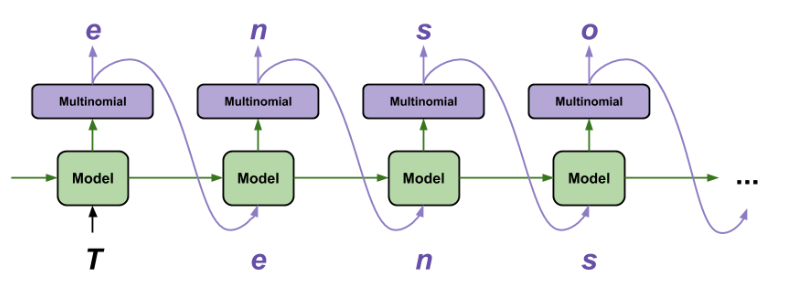

In [ ]:
def generate_text(model,input_prompt):
  input_seq = [char2int[char] for char in input_prompt]#converting raw text into integers
  input_seq = tf.expand_dims(input_seq,0)#batching the sequence,expanding dimensions along the first dimension

  num_generated = 1000 #number of characters to be generated by the model

  Temperature = 0.8 #setting a low temperature to generate most probable characters

  model.layers[1].reset_states()#clears previous training memory of LSTM hidden states
  text_generated = []

  '''
  creating a loop whereby next character generated from a sequence is fed back into the model
  to predict the next character. Each character passed updates the internal memory. Allowing the
  model to hold context
  '''

  for i in range(num_generated):
    prediction_logits = model(input_seq) #65 logits are produced, representing probabilities of the next likely character

    prediction_logits= tf.squeeze(prediction_logits,0)#removing batch dimension to allow for scaling

    scaled_logits = prediction_logits / Temperature#scaling logits to allow for randomness
    '''
    tf.random.categorical applies softmax to scaled_logits
    returns most probable next character class/id/position in vocabulary
    '''

    predicted_id = tf.random.categorical(scaled_logits,num_samples=1)[-1,0].numpy()

    '''
    reassigning new input sequence as the character that was predicted
    it is passed as a batch to align it with the model architecture
    hence expanding it along te first dimension
    and within that batch it contains a single element hence the brackets around predicted id
    converted to numpy as data type is currently in tensor
    which is dense representation of trackable entities, converted to numpy for simple integer accessing
    '''

    input_seq = tf.expand_dims([predicted_id], 0)

    text_generated.append(int2char[predicted_id])


  return input_prompt + ''.join(text_generated)





# Testing Play Generation

Enter any starting sentence or a single word to enable the model to generate a play

In [ ]:
inp = input('Enter any starting sentence or a single word of your choice:')

Enter any starting sentence or a single:Caius Marcius


In [ ]:
print(generate_text(model,inp))

Caius Marcius stoop'd at once;
The world I love the clamour of his lecture
Shall be the nurse; or a silver safetter through the rest.

CAPULET:
What noise is this? Give me my joys with laments
All the to offend him still.

GLOUCESTER:
Good Lord, how fell,
Whom I, flike queen, you wot befall'n would 'long to bedward,
And so deserves me of a prescriber
A forth; and that, being a stranger: although I find it so.
Now I'll tell you, Signior Gremio: 'tis now so to him out of mine.

PETER:
You wrong to, lest
The corin of his last; and that's enough.

Second Keeper:
Were he not pause to brook the temper of the prince,
Than clap the shepherd sounds that Romeo:
Suffice, having a tongue to questing mine;
And not a worthy blood, do not sound more first?

KING EDWARD IV:
Why, so! there is unlawful mother of my father's staff,
Much in the porter of my state as deep;
For end this land was guilty of.

DUKE VINCENTIO:
Bliss and goodness on him.

Son:
Was ever man so based by himself so parch'd.

KING R

In [ ]:
#inp = input('Enter any starting sentence or a single:')

Enter any starting sentence or a single:pride


In [ ]:
#print(generate_text(model,inp))

pride such heads
To fet us with a drum, as we have spent a bed.

BRUTUS:
All with all my heart; and may not stay alone,
Like to his regiment: but not the poor souls
Do want the castle of your boy.

VOLUMNIA:
Why, how now, boy!

AUFIDIUS:
He hath pawn'd his visagion: gracious lord, I tender
A dream or seven of the world: my son and
myself, a rancour. entreat not a guard we will be forgot.

PRINCE EDWARD:
My lord, rescue, I could I looke a course,
More fleety than feet thee in thy widow by leasen barbaims, Coriolanus, being, as I tarry; I were by forth
tus contented with our demands.
Would they were basied gone;
With us! come, let him hear nd truly sin
To think by private wretched by degrees
Or I will bring you from the churchyard with the crown,
Whose father babes where Londallion my servants da


# Conclusion

The Model was able to do a pretty good job at generating a play. Though its meaning is not fully coherent, it has learned to mimic Shakespear's writing such as  sentence structure,tone,voice etc from the shakespeare play. Its none coherence can be attributed to limited training data. If exposed to more robust plays it will be able nerate more sensical text